In [8]:
#Importamos librerías requeridas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
#Carga desde un archivo .csv sin indice
data = pd.read_csv('Analisis GAC Full7agosto 2026(SDC ).csv')
data

,Solicitudes de Credito,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Ventas,NaN,12,7,8,13,6,21,17,17,...,41,41,35,37,33,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Indicador,"Enero, 24","Febrero, 24","Marzo, 24","Abril, 24","Mayo, 24","Junio, 24","Julio, 24","Agosto, 24","Septiembre, 24",...,"Marzo, 26","Abril, 26","Mayo,26","Junio, 26","Julio,26",Total 2024,Total 2025,Total 2026,NaN,NaN
4,Generadas,5,6,11,23,26,43,55,36,56,...,85,74,95,82,32,519,1178,450,1697.0,39%
5,Aprobadas,1,2,7,14,8,13,30,19,26,...,41,42,44,35,12,215,451,201,666.0,0.509009009
6,Condicionadas,0,0,1,0,4,0,3,0,1,...,14,16,17,10,9,100,287,102,387.0,NaN
7,Rechazadas,4,4,4,9,14,22,17,13,13,...,30,16,30,33,9,163,392,137,555.0,NaN
8,Formalizadas,1,1,5,11,3,6,17,9,7,...,18,16,19,13,4,105,234,91,339.0,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
#Seleccionamos únicamente la tabla mensual de SDC
sdc = data.iloc[3:12, 0:32].copy()

#Usamos la primera fila como encabezado
sdc.columns = sdc.iloc[0]

#Eliminamos esa fila y las filas completamente vacías
sdc = sdc.iloc[1:].dropna(how='all').reset_index(drop=True)

sdc

3,Indicador,"Enero, 24","Febrero, 24","Marzo, 24","Abril, 24","Mayo, 24","Junio, 24","Julio, 24","Agosto, 24","Septiembre, 24",...,"Octubre, 25","Noviembre, 25","Diciembre, 25","Enero, 26","Febrero, 26","Marzo, 26","Abril, 26","Mayo,26","Junio, 26","Julio,26"
0,Generadas,5,6,11,23,26,43,55,36,56,...,136,118,111,113,83,85,74,95,82,32
1,Aprobadas,1,2,7,14,8,13,30,19,26,...,51,49,31,37,37,41,42,44,35,12
2,Condicionadas,0,0,1,0,4,0,3,0,1,...,22,32,49,34,21,14,16,17,10,9
3,Rechazadas,4,4,4,9,14,22,17,13,13,...,62,36,28,36,25,30,16,30,33,9
4,Formalizadas,1,1,5,11,3,6,17,9,7,...,25,24,14,21,17,18,16,19,13,4
5,% de Aprobación,20%,33%,64%,61%,31%,30%,55%,53%,46%,...,38%,42%,28%,33%,45%,48%,57%,46%,43%,38%
6,% de Formalizacion,100%,50%,71%,79%,38%,46%,57%,47%,27%,...,49%,49%,45%,57%,46%,44%,38%,43%,37%,33%


In [15]:
#Transponemos la tabla para que cada fila represente un periodo
sdc = sdc.set_index('Indicador').T.reset_index()

#Renombramos la columna de los periodos
sdc = sdc.rename(columns={sdc.columns[0]: 'Periodo'})

sdc

Indicador,Periodo,Generadas,Aprobadas,Condicionadas,Rechazadas,Formalizadas,% de Aprobación,% de Formalizacion
0,"Enero, 24",5,1,0,4,1,20%,100%
1,"Febrero, 24",6,2,0,4,1,33%,50%
2,"Marzo, 24",11,7,1,4,5,64%,71%
3,"Abril, 24",23,14,0,9,11,61%,79%
4,"Mayo, 24",26,8,4,14,3,31%,38%
5,"Junio, 24",43,13,0,22,6,30%,46%
6,"Julio, 24",55,30,3,17,17,55%,57%
7,"Agosto, 24",36,19,0,13,9,53%,47%
8,"Septiembre, 24",56,26,1,13,7,46%,27%
9,"Octubre, 24",79,31,32,12,14,39%,45%


In [16]:
#Corregimos el periodo de diciembre de 2024
sdc.loc[11, 'Periodo'] = 'Diciembre, 24'

sdc

Indicador,Periodo,Generadas,Aprobadas,Condicionadas,Rechazadas,Formalizadas,% de Aprobación,% de Formalizacion
0,"Enero, 24",5,1,0,4,1,20%,100%
1,"Febrero, 24",6,2,0,4,1,33%,50%
2,"Marzo, 24",11,7,1,4,5,64%,71%
3,"Abril, 24",23,14,0,9,11,61%,79%
4,"Mayo, 24",26,8,4,14,3,31%,38%
5,"Junio, 24",43,13,0,22,6,30%,46%
6,"Julio, 24",55,30,3,17,17,55%,57%
7,"Agosto, 24",36,19,0,13,9,53%,47%
8,"Septiembre, 24",56,26,1,13,7,46%,27%
9,"Octubre, 24",79,31,32,12,14,39%,45%


In [17]:
#Revisamos los valores nulos por columna
sdc.isnull().sum()

Indicador
Periodo                0
Generadas              0
Aprobadas              0
Condicionadas          0
Rechazadas             0
Formalizadas           0
% de Aprobación        0
% de Formalizacion     0
dtype: int64

In [18]:
#Revisamos el total de valores nulos
sdc.isnull().sum().sum()

np.int64(0)

In [19]:
#Revisamos los tipos de datos
sdc.dtypes

Indicador
Periodo                str
Generadas              str
Aprobadas              str
Condicionadas          str
Rechazadas             str
Formalizadas           str
% de Aprobación        str
% de Formalizacion     str
dtype: object

In [20]:
#Convertimos las variables cuantitativas a tipo numérico
columnas_numericas = [
    'Generadas',
    'Aprobadas',
    'Condicionadas',
    'Rechazadas',
    'Formalizadas'
]

for columna in columnas_numericas:
    sdc[columna] = pd.to_numeric(sdc[columna])

In [21]:
sdc.dtypes

Indicador
Periodo                  str
Generadas              int64
Aprobadas              int64
Condicionadas          int64
Rechazadas             int64
Formalizadas           int64
% de Aprobación          str
% de Formalizacion       str
dtype: object

In [25]:
#Convertimos las columnas de porcentaje a tipo numérico
columnas_porcentaje = [sdc.columns[-2], sdc.columns[-1]]

for columna in columnas_porcentaje:
    sdc[columna] = sdc[columna].astype(str).str.replace('%', '', regex=False)
    sdc[columna] = pd.to_numeric(sdc[columna])

In [26]:
sdc.dtypes

Indicador
Periodo                  str
Generadas              int64
Aprobadas              int64
Condicionadas          int64
Rechazadas             int64
Formalizadas           int64
% de Aprobación        int64
% de Formalizacion     int64
dtype: object

In [27]:
#Seleccionamos las variables cuantitativas
cuantitativas = sdc.select_dtypes(include=np.number)

cuantitativas

Indicador,Generadas,Aprobadas,Condicionadas,Rechazadas,Formalizadas,% de Aprobación,% de Formalizacion
0,5,1,0,4,1,20,100
1,6,2,0,4,1,33,50
2,11,7,1,4,5,64,71
3,23,14,0,9,11,61,79
4,26,8,4,14,3,31,38
5,43,13,0,22,6,30,46
6,55,30,3,17,17,55,57
7,36,19,0,13,9,53,47
8,56,26,1,13,7,46,27
9,79,31,32,12,14,39,45


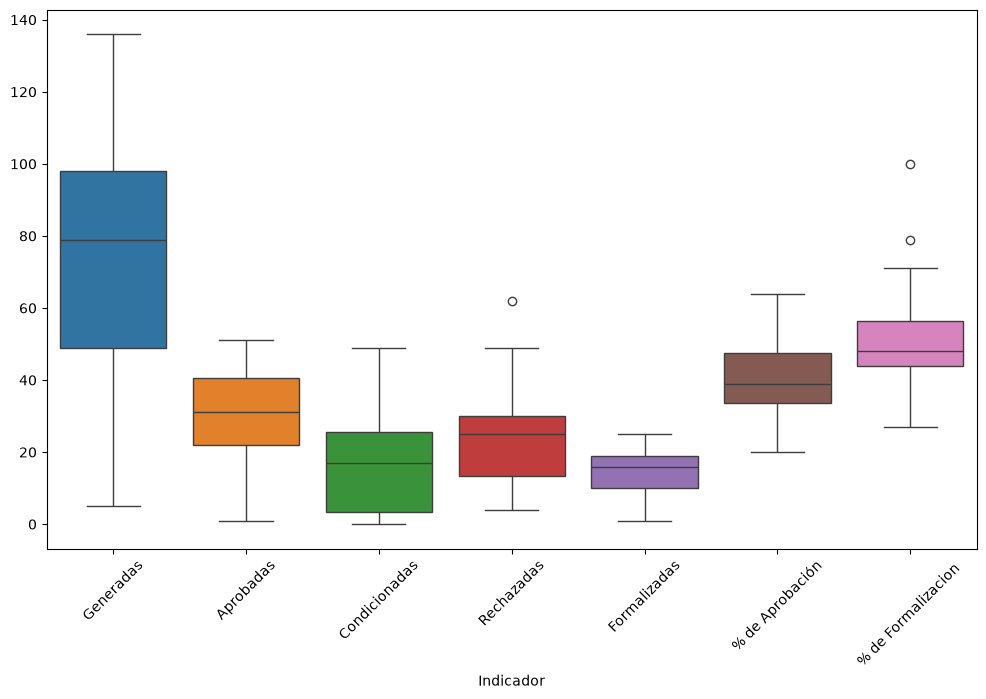

In [28]:
#Visualizamos posibles valores atípicos
plt.figure(figsize=(12, 7))
sns.boxplot(data=cuantitativas)
plt.xticks(rotation=45)
plt.show()

In [29]:
#Identificamos valores atípicos mediante el método IQR
Q1 = cuantitativas.quantile(0.25)
Q3 = cuantitativas.quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = ((cuantitativas < limite_inferior) |
            (cuantitativas > limite_superior))

outliers.sum()

Indicador
Generadas              0
Aprobadas              0
Condicionadas          0
Rechazadas             1
Formalizadas           0
% de Aprobación        0
% de Formalizacion     2
dtype: int64

In [30]:
#Mostramos las observaciones que contienen valores atípicos
sdc[outliers.any(axis=1)]

Indicador,Periodo,Generadas,Aprobadas,Condicionadas,Rechazadas,Formalizadas,% de Aprobación,% de Formalizacion
0,"Enero, 24",5,1,0,4,1,20,100
3,"Abril, 24",23,14,0,9,11,61,79
21,"Octubre, 25",136,51,22,62,25,38,49


In [31]:
#Exportamos la base limpia
sdc.to_csv('SDC_Limpio.csv', index=False)

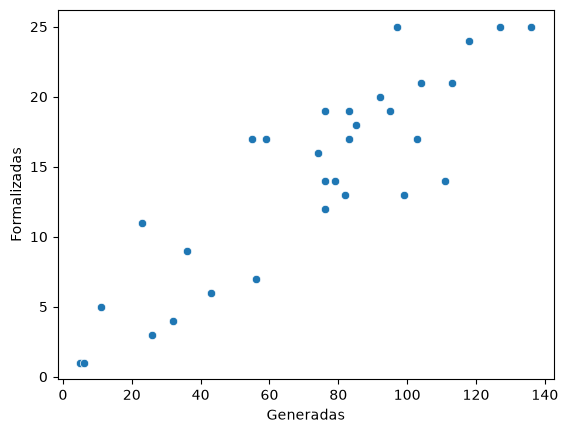

In [32]:
#Diagrama de dispersión entre Generadas y Formalizadas
sns.scatterplot(x='Generadas', y='Formalizadas', data=sdc)
plt.show()

In [33]:
#Declaramos las variables dependiente e independiente
Vars_Indep = sdc[['Generadas']]
Var_Dep = sdc['Formalizadas']

In [34]:
#Importamos el modelo de regresión lineal
from sklearn.linear_model import LinearRegression

#Creamos el modelo
model = LinearRegression()

#Entrenamos el modelo
model.fit(X=Vars_Indep, y=Var_Dep)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.17]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Generadas']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.73
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [35]:
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'tol': 1e-06,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['Generadas'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([0.17397778]),
 'rank_': np.int64(1),
 'singular_': array([197.04281506]),
 'intercept_': np.float64(1.7302015117954266)}

In [36]:
#Calculamos el coeficiente de determinación R²
model.score(Vars_Indep, Var_Dep)

0.7754234907502584

In [37]:
#Realizamos las predicciones con el modelo
y_pred = model.predict(X=sdc[['Generadas']])

y_pred

array([ 2.6000904 ,  2.77406817,  3.64395706,  5.73169038,  6.25362371,
        9.21124591, 11.29897923,  7.99340147, 11.47295701, 15.47444587,
       14.95251254, 19.64991251, 16.17035698, 14.95251254, 17.73615697,
       11.99489034, 14.95251254, 18.60604585, 19.82389029, 18.95400141,
       23.82537915, 25.39117914, 22.25957916, 21.04173473, 21.38969028,
       16.17035698, 16.51831253, 14.60455699, 18.2580903 , 15.9963792 ,
        7.29749037])

In [38]:
#Insertamos las predicciones en la base de datos
sdc.insert(0, 'Predicciones', y_pred)

sdc

Indicador,Predicciones,Periodo,Generadas,Aprobadas,Condicionadas,Rechazadas,Formalizadas,% de Aprobación,% de Formalizacion
0,2.600090,"Enero, 24",5,1,0,4,1,20,100
1,2.774068,"Febrero, 24",6,2,0,4,1,33,50
2,3.643957,"Marzo, 24",11,7,1,4,5,64,71
3,5.731690,"Abril, 24",23,14,0,9,11,61,79
4,6.253624,"Mayo, 24",26,8,4,14,3,31,38
5,9.211246,"Junio, 24",43,13,0,22,6,30,46
6,11.298979,"Julio, 24",55,30,3,17,17,55,57
7,7.993401,"Agosto, 24",36,19,0,13,9,53,47
8,11.472957,"Septiembre, 24",56,26,1,13,7,46,27
9,15.474446,"Octubre, 24",79,31,32,12,14,39,45


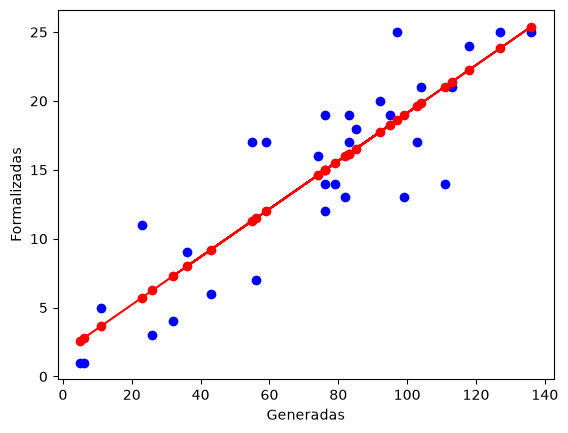

In [39]:
#Graficamos los valores reales y las predicciones
plt.scatter(sdc['Generadas'], sdc['Formalizadas'], color='blue')
plt.scatter(sdc['Generadas'], sdc['Predicciones'], color='red')
plt.plot(sdc['Generadas'], sdc['Predicciones'], color='red')

plt.xlabel('Generadas')
plt.ylabel('Formalizadas')
plt.show()

In [40]:
#Calculamos nuevamente el coeficiente de determinación
coef_Deter = model.score(Vars_Indep, Var_Dep)

coef_Deter

0.7754234907502584

In [41]:
#Calculamos el coeficiente de correlación
coef_Correl = np.sqrt(coef_Deter)

coef_Correl

np.float64(0.8805813368169112)

In [42]:
#Seleccionamos únicamente las variables numéricas
sdc_num = sdc.select_dtypes(include=np.number)

sdc_num

Indicador,Predicciones,Generadas,Aprobadas,Condicionadas,Rechazadas,Formalizadas,% de Aprobación,% de Formalizacion
0,2.600090,5,1,0,4,1,20,100
1,2.774068,6,2,0,4,1,33,50
2,3.643957,11,7,1,4,5,64,71
3,5.731690,23,14,0,9,11,61,79
4,6.253624,26,8,4,14,3,31,38
5,9.211246,43,13,0,22,6,30,46
6,11.298979,55,30,3,17,17,55,57
7,7.993401,36,19,0,13,9,53,47
8,11.472957,56,26,1,13,7,46,27
9,15.474446,79,31,32,12,14,39,45


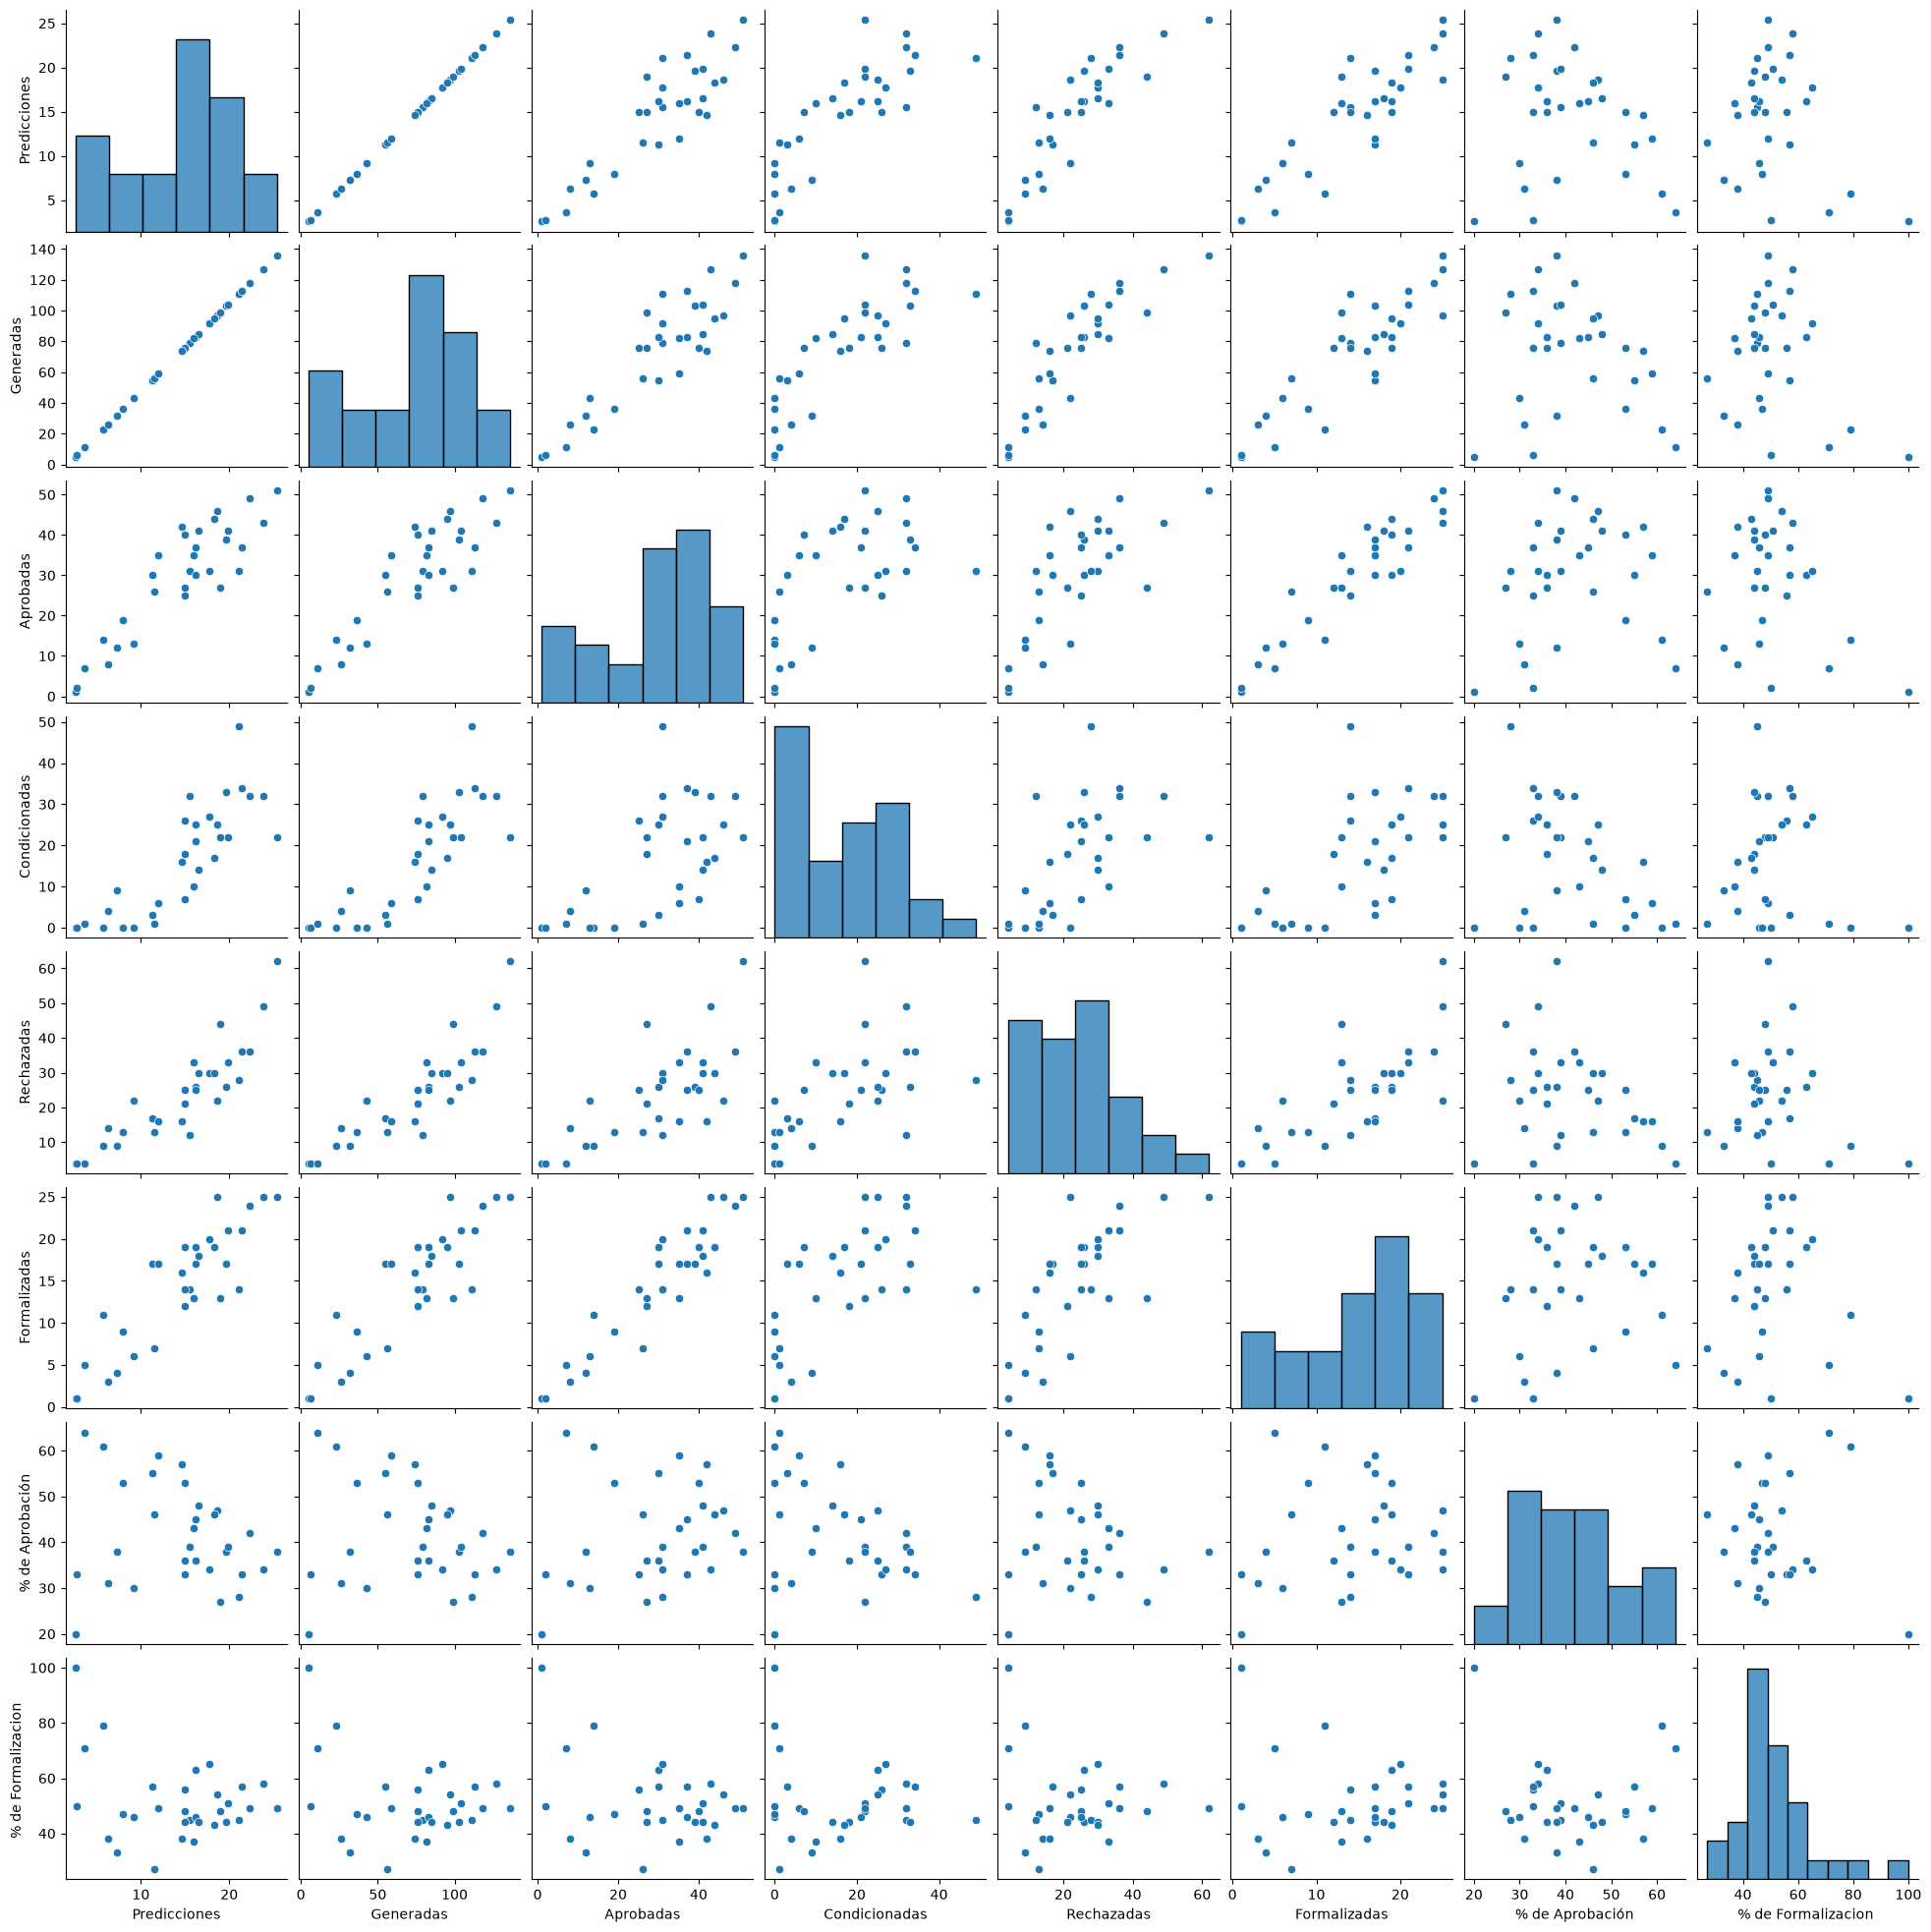

In [43]:
#Graficamos las relaciones entre las variables numéricas
sns.pairplot(sdc_num)
plt.show()

In [44]:
#Calculamos la matriz de correlaciones
Corr_Factors = sdc_num.corr()

Corr_Factors

Indicador,Predicciones,Generadas,Aprobadas,Condicionadas,Rechazadas,Formalizadas,% de Aprobación,% de Formalizacion
Indicador,,,,,,,,
Predicciones,1.000000,1.000000,0.896295,0.825762,0.881383,0.880581,-0.188326,-0.270105
Generadas,1.000000,1.000000,0.896295,0.825762,0.881383,0.880581,-0.188326,-0.270105
Aprobadas,0.896295,0.896295,1.000000,0.609925,0.725853,0.932941,0.180287,-0.326290
Condicionadas,0.825762,0.825762,0.609925,1.000000,0.588563,0.647136,-0.381168,-0.112010
Rechazadas,0.881383,0.881383,0.725853,0.588563,1.000000,0.744203,-0.279653,-0.170291
Formalizadas,0.880581,0.880581,0.932941,0.647136,0.744203,1.000000,0.143134,-0.061899
% de Aprobación,-0.188326,-0.188326,0.180287,-0.381168,-0.279653,0.143134,1.000000,-0.076145
% de Formalizacion,-0.270105,-0.270105,-0.326290,-0.112010,-0.170291,-0.061899,-0.076145,1.000000


In [45]:
#Calculamos el valor absoluto de las correlaciones
Corr_Factors1 = abs(Corr_Factors)

Corr_Factors1

Indicador,Predicciones,Generadas,Aprobadas,Condicionadas,Rechazadas,Formalizadas,% de Aprobación,% de Formalizacion
Indicador,,,,,,,,
Predicciones,1.000000,1.000000,0.896295,0.825762,0.881383,0.880581,0.188326,0.270105
Generadas,1.000000,1.000000,0.896295,0.825762,0.881383,0.880581,0.188326,0.270105
Aprobadas,0.896295,0.896295,1.000000,0.609925,0.725853,0.932941,0.180287,0.326290
Condicionadas,0.825762,0.825762,0.609925,1.000000,0.588563,0.647136,0.381168,0.112010
Rechazadas,0.881383,0.881383,0.725853,0.588563,1.000000,0.744203,0.279653,0.170291
Formalizadas,0.880581,0.880581,0.932941,0.647136,0.744203,1.000000,0.143134,0.061899
% de Aprobación,0.188326,0.188326,0.180287,0.381168,0.279653,0.143134,1.000000,0.076145
% de Formalizacion,0.270105,0.270105,0.326290,0.112010,0.170291,0.061899,0.076145,1.000000


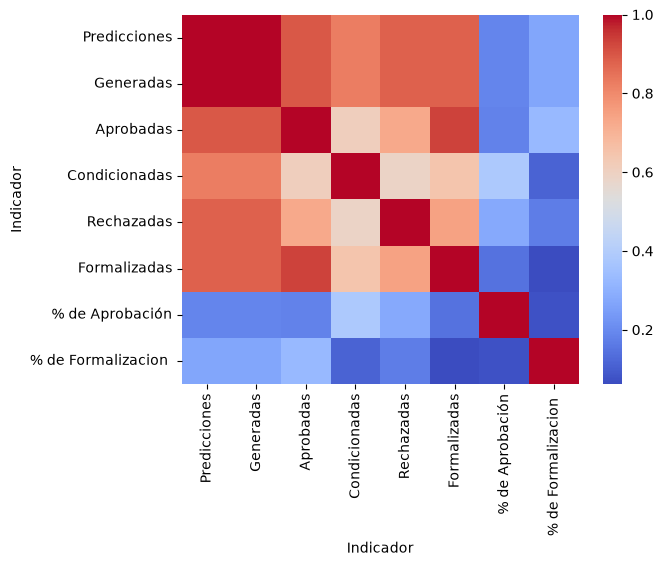

In [46]:
#Visualizamos la matriz de correlaciones
Heat_Map = sns.heatmap(Corr_Factors1, cmap='coolwarm')
plt.show()

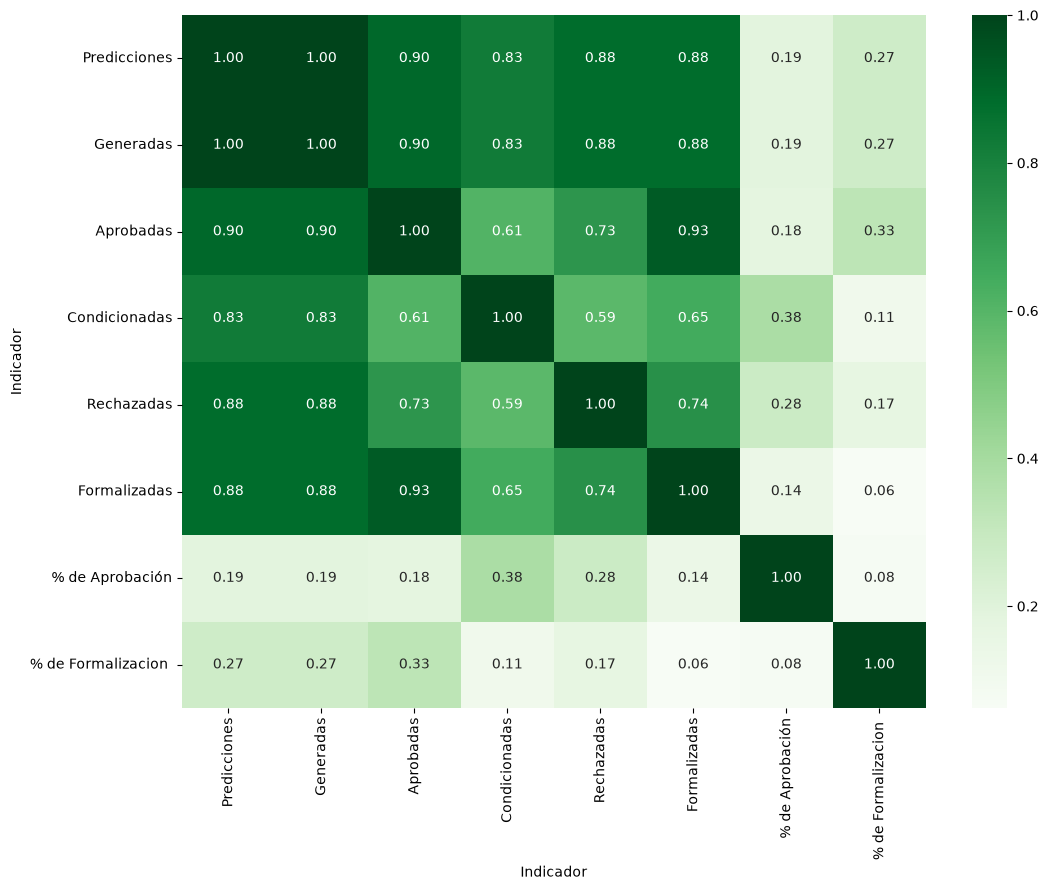

In [47]:
#Visualizamos las correlaciones con sus valores
plt.figure(figsize=(12, 9))
Heat_Map = sns.heatmap(Corr_Factors1, cmap='Greens', annot=True, fmt=".2f")
plt.show()